# Where to open a café in central Moscow?

**Applied Data Science Capstone (IBM / Coursera): the Battle of the Neighbourhoods, Moscow edition.**

This notebook completes the project started in 2019. [Notebook 01](01_data_collection_moscow_open_data.ipynb)
built a grid of candidate locations around Red Square and collected Moscow Open Data layers;
[notebook 02](02_foursquare_central_districts.ipynb) explored the central districts with Foursquare.
Here the pieces come together into a location recommendation.

1. [Introduction: the business problem](#1.-Introduction:-the-business-problem)
2. [Data](#2.-Data)
3. [Methodology](#3.-Methodology)
4. [Exploratory analysis](#4.-Exploratory-analysis)
5. [Neighbourhood typology](#5.-Neighbourhood-typology)
6. [Demand model](#6.-Demand-model)
7. [Opportunity score and shortlist](#7.-Opportunity-score-and-shortlist)
8. [Looking forward: 2019 to 2026](#8.-Looking-forward:-2019-to-2026)
9. [The shortlist for 2026](#9.-The-shortlist-for-2026)
10. [Results and discussion](#10.-Results-and-discussion)
11. [Conclusion](#11.-Conclusion)

## 1. Introduction: the business problem

Central Moscow is one of the densest café markets in Europe: within 6 km of Red Square the city
register listed almost 4,000 cafés and restaurants in 2019, and on many streets there is a coffee
shop on every corner. Opening one more café there is mostly a bet on the location. A good site
sits on a steady flow of people (commuters coming out of the metro, shoppers, visitors of
hairdressers and repair shops, students) but is not already crowded with competitors that
absorb that flow.

**Stakeholder.** An entrepreneur or a franchise developer who plans a new café (coffee,
pastries, light meals) in central Moscow and needs a short list of places worth a field visit
and a rent search.

**Question.** Which locations within 6 km of Red Square have the footfall generators that
usually support many cafés, yet host noticeably fewer cafés and restaurants than comparable
places?

**Approach.** The area is covered by 364 hexagonal cells about 590 m across. For every cell we
count what lies within 300 m: competitors, metro exits, bus stops, parking spaces, shops,
consumer services, gyms, universities. A model trained on all cells learns how many cafés and
restaurants a place with a given mix of footfall generators usually has; cells with far fewer
competitors than expected are under-served. The shortlist keeps the under-served cells that are
close to the metro and already have street retail around them.

The model is built on the city registers of 2019 and then checked against the future:
OpenStreetMap shows where cafés and restaurants are in 2026, so we can see whether the gaps found
in 2019 filled up. Finally the same pipeline, run with today's competitors and today's footfall
generators from OpenStreetMap, gives the shortlist for 2026.

## 2. Data

| Layer | Source | Used as |
|---|---|---|
| Candidate locations | Hexagonal grid within 6 km of Red Square, 600 m step (notebook 01); addresses from the Yandex Geocoder | units of analysis |
| Catering register | [data.mos.ru](https://data.mos.ru), 2019: 15,366 venues with type, seats and a chain flag | competitors (*кафе* and *ресторан*) and the rest of the catering scene |
| Metro entrances and exits | data.mos.ru, 2019 | footfall: exits within 300 m, distance to the nearest exit |
| Surface transport stops | data.mos.ru, 2019 | footfall: stops within 300 m |
| Paid street parking | data.mos.ru, 2019 | accessibility by car: parking spaces within 300 m |
| Shopping register | data.mos.ru, 2019: 60,320 shops | footfall: shops within 300 m |
| Consumer services | data.mos.ru, 2019 | footfall: hairdressers, dry cleaners, repairs... within 300 m |
| Fitness | data.mos.ru, 2019 | footfall: gyms within 300 m |
| Universities and colleges | [OpenStreetMap](https://www.openstreetmap.org/copyright), 2026 | footfall: students |
| Cafés and restaurants | OpenStreetMap, 2026 | the check of section 8: did the gaps of 2019 fill up? |
| Footfall generators | OpenStreetMap, 2026: metro, MCC and MCD entrances, stops, shops, services, gyms | the 2026 shortlist of section 9 |

Notes on the data:

* The catering and shopping registers were restored in 2026 from a backup of the 2019 Dropbox
  (`data/dropbox_2019/`). As in notebook 01, **competitors are the *кафе* and *ресторан* types of
  the catering register**; fast food, bars, canteens and buffets are described but not counted.
* The education register of 2019 (`EducationUTF.txt`, 620 organisations run by the city
  education department) holds mostly schools, 534 of them, and no federal universities, so
  universities and colleges come from OpenStreetMap. Universities rarely move, so the seven years
  between the sources matter little here.
* The fitness register lists gym halls, several per club; they are merged into 385 facilities.
  It covers mostly municipal sports centres.
* The cinema register holds only 14 municipal cinemas, too few to describe 364 cells, so it is
  not used.

In [1]:
import json
import sys
from html import escape
from pathlib import Path

import branca.colormap as bcm
import folium
import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from folium.plugins import HeatMap
from matplotlib.collections import PolyCollection
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import d2_tweedie_score, silhouette_score
from sklearn.model_selection import KFold, PredefinedSplit, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from moscow_cafes import data  # noqa: E402
from moscow_cafes.features import RADIUS_M, build_features  # noqa: E402
from moscow_cafes.geo import (  # noqa: E402
    RED_SQUARE,
    count_within,
    distance_from,
    grid_hexagons,
    nearest,
    to_xy,
    xy_array,
)

REPORT = ROOT / "report"
FIGURES = REPORT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 2)

In [2]:
# Chart styling: a light surface, hairline axes, and one colour job per chart:
# sequential blue for magnitude, red <-> gray <-> blue for "fewer / more than expected".
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA, RED, NEUTRAL = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#f0efec"
BLUE_STEPS = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("fewer_more", [RED, NEUTRAL, BLUE])
HALO = [patheffects.withStroke(linewidth=3, foreground=SURFACE)]  # keeps labels legible over map tiles

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "font.size": 10,
        "legend.frameon": False,
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    fig.savefig(FIGURES / f"{name}.png")

### Loading the layers

In [3]:
cells = data.load_candidates()
layers = {
    "catering": data.load_catering(),
    "metro": data.load_metro_exits(),
    "bus": data.load_bus_stops(),
    "parking": data.load_parking(),
    "shops": data.load_shops(),
    "services": data.load_services(),
    "fitness": data.load_fitness(),
    "education": data.load_education(),
}
osm_catering = data.load_osm_catering()
osm_meta = json.loads((ROOT / "data" / "osm" / "osm_meta.json").read_text(encoding="utf-8"))
osm_date = osm_meta["catering"]["timestamp_osm_base"][:10]

pd.DataFrame(
    [
        ("Candidate locations", len(cells), "grid of notebook 01", "2019"),
        ("Catering venues", len(layers["catering"]), "data.mos.ru, whole city", "2019"),
        ("Metro entrances and exits", len(layers["metro"]), "data.mos.ru, whole city", "2019"),
        ("Surface transport stops", len(layers["bus"]), "data.mos.ru, whole city", "2019"),
        ("Paid parking zones", len(layers["parking"]), "data.mos.ru, whole city", "2019"),
        ("Shops", len(layers["shops"]), "data.mos.ru, whole city", "2019"),
        ("Consumer services", len(layers["services"]), "data.mos.ru, whole city", "2019"),
        ("Fitness facilities", len(layers["fitness"]), "data.mos.ru, whole city", "2019"),
        ("Universities and colleges", len(layers["education"]), "OpenStreetMap, 7 km around Red Square", osm_date),
        ("Catering venues (sections 8-9)", len(osm_catering), "OpenStreetMap, 7 km around Red Square", osm_date),
        ("Footfall generators (section 9)", len(pd.read_csv(ROOT / "data" / "osm" / "osm_demand.csv")),
         "OpenStreetMap, 7 km around Red Square", osm_meta["demand"]["retrieved"]),
    ],
    columns=["Layer", "Records", "Coverage", "Vintage"],
)

,Layer,Records,Coverage,Vintage
0,Candidate locations,364,grid of notebook 01,2019
1,Catering venues,15366,"data.mos.ru, whole city",2019
2,Metro entrances and exits,1067,"data.mos.ru, whole city",2019
3,Surface transport stops,11507,"data.mos.ru, whole city",2019
4,Paid parking zones,9254,"data.mos.ru, whole city",2019
5,Shops,60320,"data.mos.ru, whole city",2019
6,Consumer services,14540,"data.mos.ru, whole city",2019
7,Fitness facilities,385,"data.mos.ru, whole city",2019
8,Universities and colleges,283,"OpenStreetMap, 7 km around Red Square",2026-09-28
9,Catering venues (sections 8-9),6729,"OpenStreetMap, 7 km around Red Square",2026-09-28


## 3. Methodology

1. **A metric projection.** All coordinates are projected to UTM zone 37N (EPSG:32637), the
   zone Moscow lies in. Notebook 01 used zone 33, whose central meridian is 22.6° west of Moscow;
   the check below shows what that did to distances.
2. **Feature engineering.** For each of the 364 candidate cells: the number of objects of every
   layer within 300 m (about four minutes on foot), the parking capacity within 300 m, and the
   distances to the nearest metro exit and to Red Square.
3. **Exploratory analysis.** The catering scene, its chains, and how competitor density relates
   to each footfall generator (Spearman correlation).
4. **Neighbourhood typology.** k-means on the standardised features groups the cells into a few
   types of urban fabric, which helps to read the maps and the shortlist.
5. **Demand model.** A Poisson regression predicts the number of competitors from the footfall
   generators alone, with gradient boosting as a flexible benchmark. Models are compared with
   **spatial cross-validation**: the city is cut into 2 × 2 km blocks and whole blocks are held
   out, so a cell is never predicted by its immediate neighbours. The out-of-fold prediction is
   the "expected" number of competitors of every cell.
6. **Opportunity score.** The standardised gap between the actual and the expected number of
   competitors, with the variance of a negative binomial distribution because the counts are
   overdispersed. The most negative scores are the under-served cells.
7. **Shortlist.** Cells with a metro exit within 500 m, at least 10 shops or services around them
   (street retail exists, so do commercial premises) and at least median expected demand, ranked
   by the opportunity score. The pipeline runs with 250, 300 and 400 m catchments and the scores
   are averaged, so the ranking does not hinge on one catchment size.
8. **Looking forward.** OpenStreetMap shows where cafés and restaurants are in 2026. If the model
   captures demand, the places it found under-served in 2019 should have gained venues since.
9. **The 2026 shortlist.** The same pipeline with the cafés and restaurants of 2026 as competitors
   and the footfall generators of 2026, both from OpenStreetMap.

In [4]:
features = build_features(cells, **layers)

# Distances from Red Square as stored by notebook 01 (UTM zone 33) versus zone 37.
legacy = pd.read_csv(ROOT / "data" / "mos_open_data" / "df_locations.csv", index_col=0)["Distance from center"]
stretch = (legacy / features["center_distance"]).mean() - 1
print(f"UTM zone 33 overstated distances by {stretch:.1%}: the farthest cell is "
      f"{legacy.max():,.0f} m away in zone 33 and {features['center_distance'].max():,.0f} m in reality.")

features.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

UTM zone 33 overstated distances by 2.4%: the farthest cell is 5,992 m away in zone 33 and 5,851 m in reality.


,mean,std,min,25%,50%,75%,max
cafes,6.98,9.47,0.0,1.00,3.00,9.00,53.00
restaurants,3.07,4.82,0.0,0.00,1.00,4.00,31.00
competitors,10.05,13.13,0.0,2.00,5.00,13.00,79.00
fast_food,1.16,2.65,0.0,0.00,0.00,1.00,21.00
bars,1.16,2.31,0.0,0.00,0.00,1.00,15.00
metro_exits,0.74,1.99,0.0,0.00,0.00,0.00,15.00
metro_distance,570.96,316.66,3.6,334.18,545.12,763.02,1648.36
bus_stops,4.18,2.97,0.0,2.00,4.00,6.00,17.00
parking_spaces,131.87,107.81,0.0,39.00,121.50,191.50,510.00
shops,31.20,84.96,0.0,4.00,11.50,26.00,1316.00


## 4. Exploratory analysis

### The catering scene

In [5]:
catering = layers["catering"]
central = catering[distance_from(catering, *RED_SQUARE) <= 6000]
composition = central.groupby(["type", "amenity"]).size().rename("venues").reset_index("amenity")
composition = composition.sort_values("venues", ascending=False)
composition["share, %"] = (100 * composition["venues"] / composition["venues"].sum()).round(1)

competitors = central[central["is_competitor"]]
chain_counts = competitors.loc[competitors["is_chain"], "chain"].value_counts()
print(f"Within 6 km of Red Square: {len(central):,} catering venues, of which {len(competitors):,} "
      f"cafés and restaurants (the competitors) with {competitors['seats'].sum():,.0f} seats.")
print(f"{competitors['is_chain'].mean():.0%} of the cafés and restaurants belong to chains.")
composition

Within 6 km of Red Square: 5,784 catering venues, of which 3,956 cafés and restaurants (the competitors) with 233,174 seats.
22% of the cafés and restaurants belong to chains.


,amenity,venues,"share, %"
type,,,
кафе,cafe,2747,47.5
ресторан,restaurant,1209,20.9
столовая,other,547,9.5
бар,bar,450,7.8
предприятие быстрого обслуживания,fast_food,377,6.5
буфет,other,201,3.5
кафетерий,other,130,2.2
закусочная,fast_food,71,1.2
магазин (отдел кулинарии),other,52,0.9


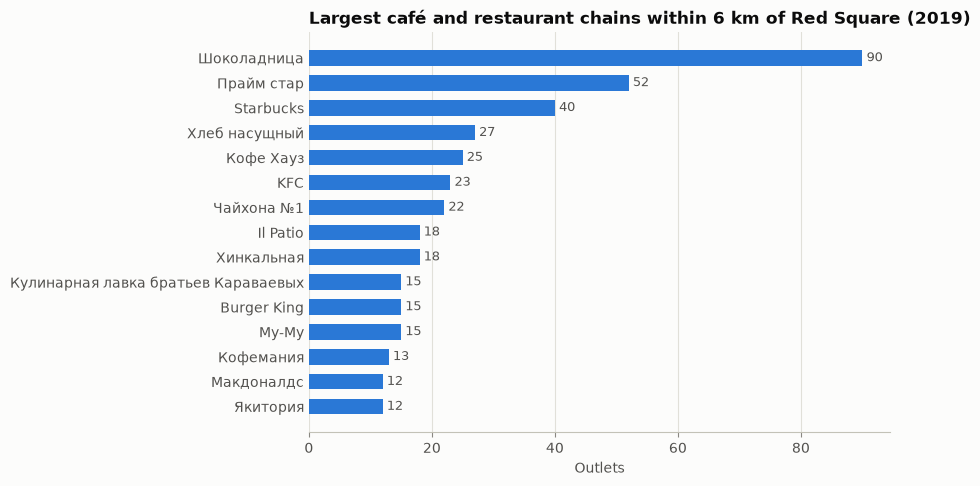

In [6]:
top_chains = chain_counts.head(15).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 5.2))
bars = ax.barh(top_chains.index, top_chains.values, color=BLUE, height=0.62)
ax.bar_label(bars, padding=3, color=INK_2, fontsize=9)
ax.set_title("Largest café and restaurant chains within 6 km of Red Square (2019)")
ax.set_xlabel("Outlets")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig1_top_chains")
plt.show()

Chain names are normalised with the rules of the 2019 cleaning script. Шоколадница leads by far,
followed by Prime (*Прайм стар*), Starbucks, Хлеб насущный and Кофе Хауз, with KFC as the first
fast-food chain registered as a café. Chains run only about a fifth of the cafés and restaurants:
the market is mostly independent venues.

### Where the competitors are

The candidate cells are drawn as the hexagons of the grid; the static maps use kilometres from
Red Square as coordinates.

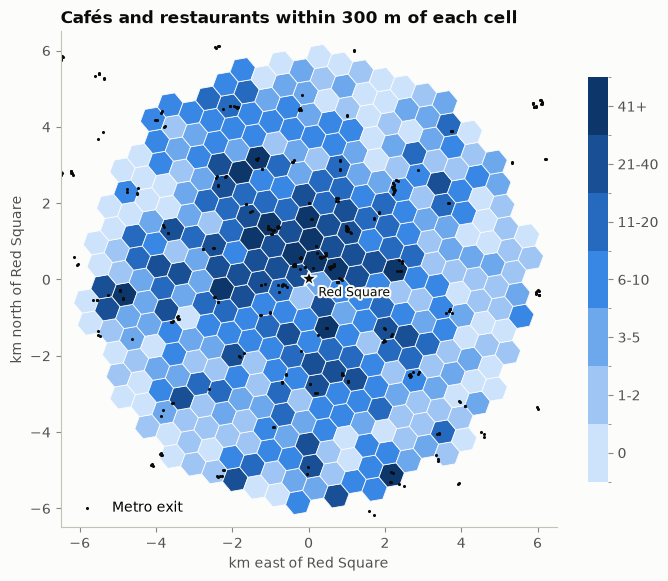

In [7]:
HEX_LATLON = grid_hexagons(cells["lat"], cells["lon"])
hex_x, hex_y = to_xy(HEX_LATLON[..., 0], HEX_LATLON[..., 1])
center_x, center_y = to_xy(*RED_SQUARE)
HEX_KM = np.stack([(hex_x - center_x) / 1000, (hex_y - center_y) / 1000], axis=-1)
CELL_KM = HEX_KM.mean(axis=1)
EXTENT_KM = 6.5


def hex_map(ax, values, cmap, norm, title, **collection_kwargs):
    """Draw the grid as a choropleth of `values` (one per cell, in cell order)."""
    tiles = PolyCollection(
        HEX_KM, array=np.asarray(values, dtype=float), cmap=cmap, norm=norm,
        edgecolor=SURFACE, linewidth=0.6, **collection_kwargs,
    )
    ax.add_collection(tiles)
    ax.set_xlim(-EXTENT_KM, EXTENT_KM)
    ax.set_ylim(-EXTENT_KM, EXTENT_KM)
    ax.set_aspect("equal")
    ax.plot(0, 0, marker="*", markersize=12, color=INK, markeredgecolor=SURFACE, markeredgewidth=1.2)
    ax.annotate("Red Square", (0, 0), xytext=(7, -12), textcoords="offset points", color=INK, fontsize=9,
                path_effects=HALO)
    ax.set_xlabel("km east of Red Square")
    ax.set_ylabel("km north of Red Square")
    ax.set_title(title)
    return tiles


metro = layers["metro"]
metro_xy = xy_array(metro)
metro_km = (metro_xy - [center_x, center_y]) / 1000
metro_km = metro_km[np.abs(metro_km).max(axis=1) < EXTENT_KM]

bins = [0, 1, 3, 6, 11, 21, 41, 1000]
fig, ax = plt.subplots(figsize=(8, 7))
tiles = hex_map(ax, features["competitors"], ListedColormap(BLUE_STEPS), BoundaryNorm(bins, len(BLUE_STEPS)),
                "Cafés and restaurants within 300 m of each cell")
ax.scatter(*metro_km.T, s=5, color=INK, linewidths=0, label="Metro exit")
colorbar = fig.colorbar(tiles, ax=ax, shrink=0.75, ticks=[0.5, 2, 4.5, 8.5, 16, 31, 520])
colorbar.ax.set_yticklabels(["0", "1-2", "3-5", "6-10", "11-20", "21-40", "41+"])
colorbar.outline.set_visible(False)
ax.legend(loc="lower left")
save(fig, "fig2_competitors_map")
plt.show()

The same picture on an interactive map: the heat map shows the competitors, the grey hexagons are
the candidate cells, the dots are metro exits. (GitHub does not render these maps; open the
notebook in [nbviewer](https://nbviewer.org/github/petro1eum/capstone/blob/master/notebooks/03_cafe_location_analysis.ipynb)
or run it locally.)

In [8]:
def base_map():
    fmap = folium.Map(location=RED_SQUARE, zoom_start=12, tiles="OpenStreetMap", control_scale=True)
    folium.Marker(RED_SQUARE, tooltip="Red Square", icon=folium.Icon(color="gray", icon="star")).add_to(fmap)
    return fmap


def hex_layer(table, fill, tooltip_fields, tooltip_aliases, name, opacity=0.6, show=True):
    """GeoJSON layer of the grid hexagons; `table` is indexed by cell, `fill` holds hex colours."""
    records = json.loads(table[tooltip_fields].to_json(orient="records", force_ascii=False))
    features_geojson = []
    for cell_id, record in zip(table.index, records, strict=True):
        ring = [[lon, lat] for lat, lon in HEX_LATLON[cells.index.get_loc(cell_id)]]
        features_geojson.append({
            "type": "Feature",
            "geometry": {"type": "Polygon", "coordinates": [ring + [ring[0]]]},
            "properties": {**{k: escape(v) if isinstance(v, str) else v for k, v in record.items()},
                           "fill": fill.loc[cell_id]},
        })
    return folium.GeoJson(
        {"type": "FeatureCollection", "features": features_geojson},
        name=name,
        show=show,
        style_function=lambda f: {"fillColor": f["properties"]["fill"], "fillOpacity": opacity,
                                  "color": SURFACE, "weight": 0.8},
        highlight_function=lambda f: {"weight": 2.5, "color": INK},
        tooltip=folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases, sticky=True),
    )


overview = cells[["address"]].join(features[["competitors", "metro_exits", "shops", "services"]])
grid_map = base_map()
hex_layer(overview, pd.Series(NEUTRAL, index=overview.index), list(overview.columns),
          ["Address", "Cafés and restaurants", "Metro exits", "Shops", "Services"], "Candidate cells",
          opacity=0.3).add_to(grid_map)
HeatMap(competitors[["lat", "lon"]].to_numpy().tolist(), name="Competitors", radius=12, blur=15,
        min_opacity=0.25).add_to(grid_map)
central_metro = metro[distance_from(metro, *RED_SQUARE) <= 6500]
metro_layer = folium.FeatureGroup(name="Metro exits")
for _, exit_ in central_metro.iterrows():
    folium.CircleMarker([exit_["lat"], exit_["lon"]], radius=2, color=INK, weight=1, fill=True,
                        fill_opacity=1, tooltip=exit_["name"]).add_to(metro_layer)
metro_layer.add_to(grid_map)
folium.LayerControl(collapsed=False).add_to(grid_map)
grid_map

Competitors crowd inside the Garden Ring and along the radial streets, and thin out towards the
Third Ring Road, apart from hot spots around big transport hubs. Which footfall generators go
together with them?

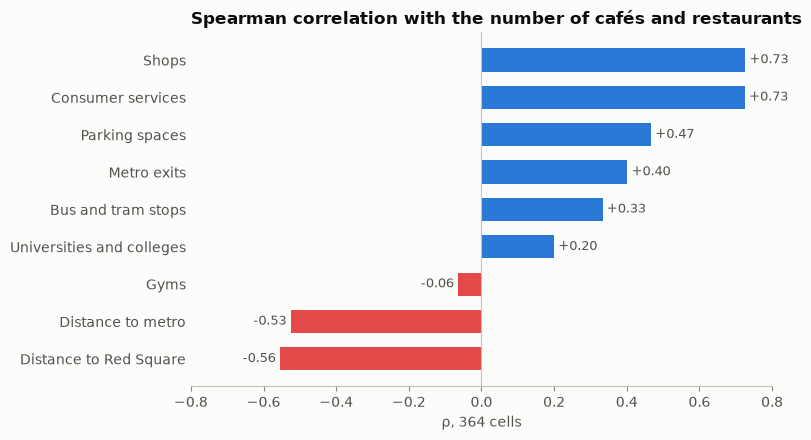

,Spearman ρ
Distance to Red Square,-0.56
Distance to metro,-0.53
Gyms,-0.06
Universities and colleges,0.20
Bus and tram stops,0.33
Metro exits,0.40
Parking spaces,0.47
Consumer services,0.73
Shops,0.73


In [9]:
drivers = ["metro_exits", "metro_distance", "bus_stops", "parking_spaces", "shops", "services",
           "fitness", "education", "center_distance"]
labels = {
    "metro_exits": "Metro exits", "metro_distance": "Distance to metro", "bus_stops": "Bus and tram stops",
    "parking_spaces": "Parking spaces", "shops": "Shops", "services": "Consumer services", "fitness": "Gyms",
    "education": "Universities and colleges", "center_distance": "Distance to Red Square",
}
rho = features[drivers].corrwith(features["competitors"], method="spearman").sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
bars = ax.barh([labels[d] for d in rho.index], rho.values, color=[BLUE if v > 0 else RED for v in rho.values],
               height=0.62)
ax.bar_label(bars, fmt="%+.2f", padding=3, color=INK_2, fontsize=9)
ax.axvline(0, color=AXIS, linewidth=0.8)
ax.set_xlim(-0.8, 0.8)
ax.set_title("Spearman correlation with the number of cafés and restaurants")
ax.set_xlabel("ρ, 364 cells")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig3_correlations")
plt.show()
rho.rename(index=labels).to_frame("Spearman ρ")

Competitors go together with consumer services, shops and parking (all mark streets with
ground-floor commerce), and they fall with the distance to the metro and to Red Square. Bus stops
and universities matter less; the municipal gyms of the fitness register sit in residential areas
and have no relation to cafés at all.

## 5. Neighbourhood typology

k-means on the standardised features (counts log-transformed, distances in km). The silhouette
score is low for every k, which is normal for a city: urban fabric changes gradually rather than
in separated clumps. k = 2 splits the cells only into "busy" and "quiet", so k = 4, where the
inertia curve bends and the clusters are still easy to name, is used to describe the area.

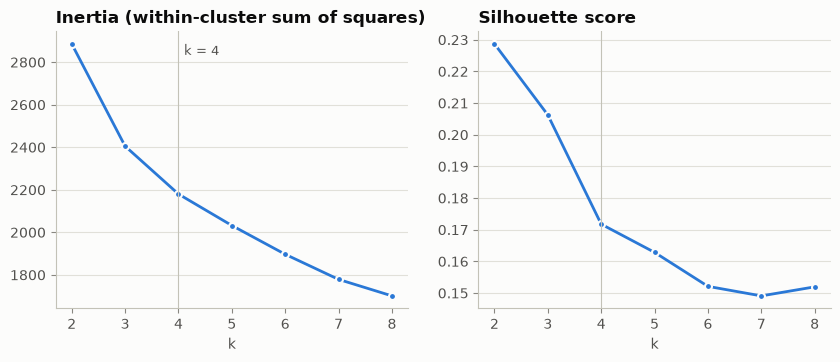

k,2,3,4,5,6,7,8
inertia,2885.97,2405.16,2179.91,2032.11,1896.69,1778.69,1701.17
silhouette,0.23,0.21,0.17,0.16,0.15,0.15,0.15


In [10]:
typology_columns = ["competitors", "fast_food", "bars", "metro_exits", "bus_stops", "parking_spaces",
                    "shops", "services", "education"]
typology_input = np.log1p(features[typology_columns]).assign(
    metro_distance_km=features["metro_distance"] / 1000,
    center_distance_km=features["center_distance"] / 1000,
)
Z = StandardScaler().fit_transform(typology_input)
k_values = list(range(2, 9))
kmeans_fits = {k: KMeans(n_clusters=k, n_init=20, random_state=0).fit(Z) for k in k_values}
k_scores = pd.DataFrame(
    {"inertia": [kmeans_fits[k].inertia_ for k in k_values],
     "silhouette": [silhouette_score(Z, kmeans_fits[k].labels_) for k in k_values]},
    index=pd.Index(k_values, name="k"),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, column, title in zip(
    axes, k_scores.columns, ["Inertia (within-cluster sum of squares)", "Silhouette score"], strict=True
):
    ax.plot(k_scores.index, k_scores[column], color=BLUE, linewidth=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.axvline(4, color=AXIS, linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
axes[0].annotate("k = 4", (4, k_scores["inertia"].max()), xytext=(4, 0), textcoords="offset points",
                 color=INK_2, fontsize=9, va="top")
save(fig, "fig4_kmeans_selection")
plt.show()
k_scores.round(3).T

In [11]:
K = 4
cluster_ids = pd.Series(kmeans_fits[K].labels_, index=cells.index)
profile = features.groupby(cluster_ids).median()

# Name the clusters by their profile, so the names do not depend on k-means label numbers.
hubs = profile["metro_exits"].idxmax()
quiet = (profile["shops"] + profile["services"]).idxmin()
central_id, residential_id = sorted(set(profile.index) - {hubs, quiet}, key=lambda c: profile.loc[c, "center_distance"])
CLUSTER_NAMES = {
    hubs: "Transit hubs",
    central_id: "Central neighbourhoods",
    residential_id: "Residential belt",
    quiet: "Parks, rail and industrial land",
}
assert len(set(CLUSTER_NAMES)) == K
CLUSTER_ORDER = ["Transit hubs", "Central neighbourhoods", "Residential belt", "Parks, rail and industrial land"]
CLUSTER_COLORS = dict(zip(CLUSTER_ORDER, [BLUE, ORANGE, AQUA, "#d9d8d2"], strict=True))
cluster = cluster_ids.map(CLUSTER_NAMES)

cluster_profile = features.groupby(cluster).median().reindex(CLUSTER_ORDER)
cluster_profile.insert(0, "cells", cluster.value_counts())
cluster_profile[["cells", "competitors", "fast_food", "bars", "metro_exits", "metro_distance", "bus_stops",
                 "parking_spaces", "shops", "services", "education", "center_distance"]].round(0).astype(int)

,cells,competitors,fast_food,bars,metro_exits,metro_distance,bus_stops,parking_spaces,shops,services,education,center_distance
Transit hubs,45,26,3,2,4,138,6,136,60,15,0,3301
Central neighbourhoods,76,15,0,2,0,438,4,204,22,12,1,2503
Residential belt,157,4,0,0,0,573,4,140,12,5,0,4315
"Parks, rail and industrial land",86,0,0,0,0,773,1,4,1,0,0,5082


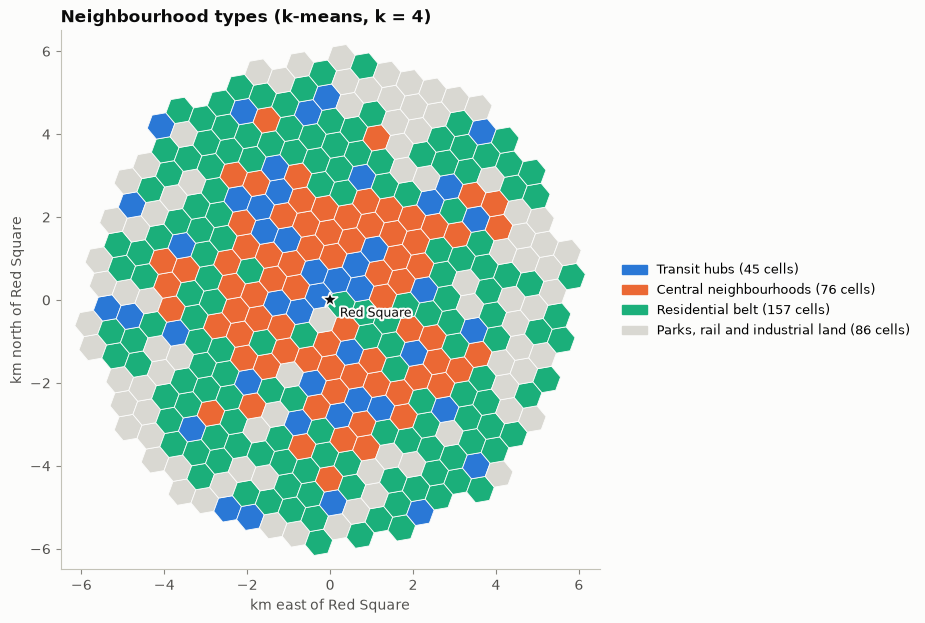

In [12]:
fig, ax = plt.subplots(figsize=(8, 7))
cluster_codes = cluster.map({name: i for i, name in enumerate(CLUSTER_ORDER)})
hex_map(ax, cluster_codes, ListedColormap([CLUSTER_COLORS[n] for n in CLUSTER_ORDER]),
        BoundaryNorm(np.arange(-0.5, K), K), "Neighbourhood types (k-means, k = 4)")
ax.legend(handles=[Patch(color=CLUSTER_COLORS[n], label=f"{n} ({(cluster == n).sum()} cells)") for n in CLUSTER_ORDER],
          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
save(fig, "fig5_typology_map")
plt.show()

* **Transit hubs**: cells around metro stations, from Okhotny Ryad, Lubyanka and Pushkinskaya in
  the centre to Paveletskaya, Kievskaya, Delovoy Tsentr and Dubrovka further out, with several
  exits within 300 m, the most shops and services and the densest catering, fast food included.
* **Central neighbourhoods**: the historic centre and the old streets around the Garden Ring, a
  couple of kilometres from Red Square: many cafés, restaurants and bars, the most paid parking,
  the metro a few hundred metres away.
* **Residential belt**: mostly the ring between the Garden Ring and the Third Ring Road, with
  modest retail and a handful of cafés per cell.
* **Parks, rail and industrial land**: Luzhniki, Gorky Park, Sokolniki, Krasnaya Presnya and
  Petrovsky parks, the Danilovskoye, Kalitnikovskoye, Rogozhskoye and Vagankovskoye cemeteries,
  rail land around the Three Stations, Rizhsky and Paveletsky stations, former factories: hardly
  any shops, services or parking, and nowhere to open a café.

In [13]:
typology_map = base_map()
typology_table = cells[["address"]].assign(type=cluster).join(
    features[["competitors", "metro_exits", "shops", "services"]])
hex_layer(typology_table, cluster.map(CLUSTER_COLORS), list(typology_table.columns),
          ["Address", "Type", "Cafés and restaurants", "Metro exits", "Shops", "Services"],
          "Neighbourhood types", opacity=0.55).add_to(typology_map)
typology_map

## 6. Demand model

The model predicts the number of competitors of a cell from its footfall generators only: metro
exits, bus stops, parking, shops, services, gyms, universities, and the distances to the metro and
to Red Square. Catering itself is left out of the inputs, because it is what we want to explain.
Counts enter as `log(1 + x)` (the tenth shop adds less than the first), capped at the 99th
percentile: one cell holds the Dubrovka clothing market with 1,316 registered stalls.

In [14]:
COUNT_DRIVERS = ["metro_exits", "bus_stops", "parking_spaces", "shops", "services", "fitness", "education"]


def design_matrix(features, distances="linear"):
    """Model inputs: log counts of the footfall generators and the two distances."""
    X = pd.DataFrame(index=features.index)
    for column in COUNT_DRIVERS:
        X[column] = np.log1p(features[column].clip(upper=features[column].quantile(0.99)))
    for column in ["metro_distance", "center_distance"]:
        km = features[column] / 1000
        X[f"{column}_km"] = np.log(km) if distances == "log" else km
    return X


# Spatial cross-validation: the cells are grouped into 2 x 2 km blocks and the blocks are dealt at
# random into 6 folds. RandomState and PredefinedSplit keep the folds the same in every library version.
BLOCK_M = 2000
block_xy = np.floor(xy_array(cells) / BLOCK_M).astype(int)
blocks = np.unique(block_xy, axis=0, return_inverse=True)[1].ravel()
cell_fold = (np.random.RandomState(0).permutation(blocks.max() + 1) % 6)[blocks]
spatial_cv = PredefinedSplit(cell_fold)


def glm(alpha):
    return make_pipeline(StandardScaler(), PoissonRegressor(alpha=alpha, max_iter=2000))


def boosting():
    return HistGradientBoostingRegressor(loss="poisson", learning_rate=0.03, max_iter=300, max_depth=3,
                                         min_samples_leaf=20, random_state=0)


def out_of_fold(model, X, y, cv=spatial_cv):
    return pd.Series(cross_val_predict(model, X, y, cv=cv), index=X.index)


def d2(y, prediction):
    """Share of the Poisson deviance explained, the R² of count models."""
    return d2_tweedie_score(y, prediction, power=1)


y = features["competitors"]
X_linear, X_log = design_matrix(features), design_matrix(features, distances="log")
fold_sizes = np.bincount(cell_fold)
print(f"{blocks.max() + 1} spatial blocks in 6 folds of {fold_sizes.min()}-{fold_sizes.max()} cells")

alpha_scores = pd.Series({a: d2(y, out_of_fold(glm(a), X_linear, y)) for a in [0.1, 0.3, 1, 3, 10]})
ALPHA = alpha_scores.idxmax()
print("GLM regularisation, D² by alpha:", alpha_scores.round(3).to_dict(), "-> alpha =", ALPHA)

38 spatial blocks in 6 folds of 46-72 cells


GLM regularisation, D² by alpha: {0.1: 0.662, 0.3: 0.666, 1.0: 0.67, 3.0: 0.66, 10.0: 0.596} -> alpha = 1.0


In [15]:
predictions = {
    "Poisson GLM, log distances": out_of_fold(glm(ALPHA), X_log, y),
    "Poisson GLM, linear distances": out_of_fold(glm(ALPHA), X_linear, y),
    "Gradient boosting, Poisson loss": out_of_fold(boosting(), X_linear, y),
}
predictions["Average of the GLM and boosting"] = (
    predictions["Poisson GLM, linear distances"] + predictions["Gradient boosting, Poisson loss"]
) / 2
model_comparison = pd.Series({name: d2(y, p) for name, p in predictions.items()}, name="D², spatial CV").to_frame()
random_cv_d2 = d2(y, out_of_fold(glm(ALPHA), X_linear, y, cv=KFold(6, shuffle=True, random_state=0)))
print(f"The same GLM under an ordinary random 6-fold split: D² = {random_cv_d2:.3f}")
model_comparison.round(3)

The same GLM under an ordinary random 6-fold split: D² = 0.664


,"D², spatial CV"
"Poisson GLM, log distances",0.62
"Poisson GLM, linear distances",0.67
"Gradient boosting, Poisson loss",0.62
Average of the GLM and boosting,0.67


* Distances enter better linearly than as logarithms. In a log-link model a linear term means
  the expected density decays exponentially with distance, the classic density gradient of
  urban economics; the logarithm explodes next to Red Square and predicts cafés inside the
  Kremlin walls.
* Gradient boosting does not beat the linear model and averaging the two adds nothing, so the
  interpretable GLM gives the expected number of competitors. (Boosting results also move a little
  between scikit-learn versions; the GLM's do not.)
* About two thirds of the deviance is explained by the footfall generators alone; the rest comes
  from what the data does not see (offices, tourists, food halls, the character of a street).
* An ordinary random split scores the GLM almost the same as the spatial one. The 300 m
  catchments of neighbouring cells barely overlap, so leakage between neighbours does not inflate
  the score here; the spatial blocks are kept as the stricter test.

How much does each generator matter? The GLM refitted on all cells, with 95% intervals from a
block bootstrap (the 2 km blocks are resampled, 300 times):

In [16]:
model = glm(ALPHA).fit(X_linear, y)
coefficients = pd.Series(model[-1].coef_ / model[0].scale_, index=X_linear.columns)

rng = np.random.RandomState(0)
block_ids = np.unique(blocks)
bootstrap = []
for _ in range(300):
    rows = np.concatenate([np.flatnonzero(blocks == b) for b in rng.choice(block_ids, size=len(block_ids))])
    fit = glm(ALPHA).fit(X_linear.iloc[rows], y.iloc[rows])
    bootstrap.append(fit[-1].coef_ / fit[0].scale_)
bootstrap = pd.DataFrame(bootstrap, columns=X_linear.columns)

# Express coefficients as % change of the expected number of competitors.
units = {c: ("twice as many", np.log(2)) for c in COUNT_DRIVERS}
units["metro_distance_km"] = ("100 m farther", 0.1)
units["center_distance_km"] = ("1 km farther", 1.0)
effect_labels = {**labels, "metro_distance_km": "Metro exit", "center_distance_km": "Red Square"}


def to_effect(b, column):
    return 100 * (np.exp(b * units[column][1]) - 1)


effects = pd.DataFrame({
    "change": [f"{effect_labels[c]}: {units[c][0]}" for c in X_linear.columns],
    "effect, %": [to_effect(coefficients[c], c) for c in X_linear.columns],
    "95% low": [to_effect(bootstrap[c].quantile(0.025), c) for c in X_linear.columns],
    "95% high": [to_effect(bootstrap[c].quantile(0.975), c) for c in X_linear.columns],
}, index=X_linear.columns).sort_values("effect, %")
effects

,change,"effect, %",95% low,95% high
center_distance_km,Red Square: 1 km farther,-21.94,-28.23,-17.25
fitness,Gyms: twice as many,-5.93,-26.36,17.48
metro_distance_km,Metro exit: 100 m farther,-4.50,-6.93,-1.95
education,Universities and colleges: twice as many,-3.35,-11.88,7.00
bus_stops,Bus and tram stops: twice as many,-0.67,-9.24,9.48
parking_spaces,Parking spaces: twice as many,3.11,-1.32,7.71
metro_exits,Metro exits: twice as many,8.04,0.30,15.96
services,Consumer services: twice as many,18.38,9.22,29.51
shops,Shops: twice as many,25.65,21.12,30.42


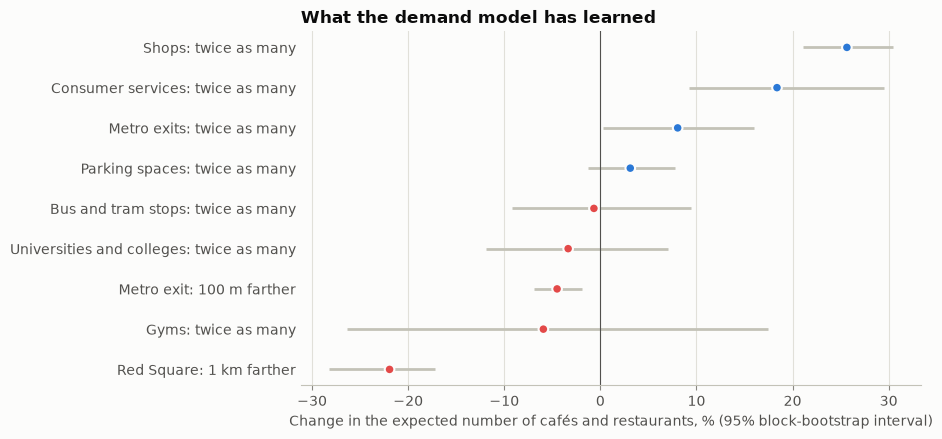

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.6))
positions = np.arange(len(effects))
ax.hlines(positions, effects["95% low"], effects["95% high"], color=AXIS, linewidth=2)
ax.scatter(effects["effect, %"], positions, s=48, color=[BLUE if v > 0 else RED for v in effects["effect, %"]],
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.axvline(0, color=INK_2, linewidth=0.8)
ax.set_yticks(positions, effects["change"])
ax.set_xlabel("Change in the expected number of cafés and restaurants, % (95% block-bootstrap interval)")
ax.set_title("What the demand model has learned")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
save(fig, "fig6_model_effects")
plt.show()

## 7. Opportunity score and shortlist

The expected number of competitors of each cell comes from a model that never saw the cell's
block. The counts are strongly overdispersed (see the dispersion printed below), so the gap is
standardised with a negative binomial variance, `expected + expected² / θ`, instead of the Poisson
one; otherwise the busiest cells would dominate the ranking just because their counts are large.

The 300 m catchment is a convention, and the answer should not hinge on it (the modifiable areal
unit problem). The whole pipeline (features, models, gap, eligibility) is therefore run with 250,
300 and 400 m catchments, and the three gaps are averaged into the **opportunity score**.

A cell is **eligible** when, for at least two of the three catchments, it has a metro exit within
500 m, at least 10 shops and services around it (there is street retail, so there are commercial
premises) and at least the median expected demand. Eligible cells are ranked by the opportunity
score, most under-served first. The `competitors` and `expected` columns are for 300 m.

In [18]:
def opportunity(features, competitor_columns=("competitors",)):
    """Expected competitors (GLM, out of fold), gap score and eligibility."""
    y = features[list(competitor_columns)].sum(axis=1)
    X = design_matrix(features)
    expected = out_of_fold(glm(ALPHA), X, y)
    residual = y - expected
    theta = (expected ** 2).sum() / (residual ** 2 - expected).sum()  # negative binomial, method of moments
    gap = residual / np.sqrt(expected + expected ** 2 / theta)
    eligible = (
        (features["metro_distance"] <= 500)
        & (features["shops"] + features["services"] >= 10)
        & (expected >= expected.median())
    )
    return pd.DataFrame({"expected": expected, "gap": gap, "eligible": eligible}), theta


RADII = (250, 300, 400)
features_by_radius = {r: features if r == RADIUS_M else build_features(cells, **layers, radius=r) for r in RADII}


def multi_scale(features_by_radius, competitor_columns=("competitors",)):
    """Gap averaged over the three catchments; eligible when eligible for at least two of them."""
    runs = {r: opportunity(features_by_radius[r], competitor_columns)[0] for r in RADII}
    score = pd.concat({r: runs[r]["gap"] for r in RADII}, axis=1).mean(axis=1)
    eligible = pd.concat({r: runs[r]["eligible"] for r in RADII}, axis=1).sum(axis=1) >= 2
    return score, eligible, runs


opportunity_score, eligible, runs = multi_scale(features_by_radius)
run, theta = opportunity(features)
residual = y - run["expected"]
dispersion = (residual ** 2 / run["expected"]).sum() / (len(y) - X_linear.shape[1] - 1)
print(f"300 m: Pearson dispersion {dispersion:.1f} (1 would mean Poisson), negative binomial θ = {theta:.2f}")
print(f"{eligible.sum()} of {len(cells)} cells are eligible")

def score_table(features, expected, score, eligible, exits):
    """One row per cell: where it is, what surrounds it, its expectation and its opportunity score."""
    _, nearest_exit = nearest(xy_array(cells), xy_array(exits))
    return cells[["address"]].assign(
        type=cluster,
        nearest_metro=exits["station"].to_numpy()[nearest_exit],
        metro_m=features["metro_distance"].round(),
        center_km=(features["center_distance"] / 1000).round(1),
        competitors=features["competitors"],
        expected=expected.round(1),
        score=score.round(2),
        eligible=eligible,
        shops=features["shops"],
        services=features["services"],
        lat=cells["lat"].round(6),
        lon=cells["lon"].round(6),
    )


def top_ten(scores):
    shortlist = scores[scores["eligible"]].sort_values("score").head(10)
    shortlist.insert(0, "rank", range(1, len(shortlist) + 1))
    return shortlist


scores = score_table(features, run["expected"], opportunity_score, eligible, metro)
shortlist = top_ten(scores)
shortlist.drop(columns=["eligible", "lat", "lon"])

300 m: Pearson dispersion 5.5 (1 would mean Poisson), negative binomial θ = 4.00
117 of 364 cells are eligible


,rank,address,type,nearest_metro,metro_m,center_km,competitors,expected,score,shops,services
cell_id,,,,,,,,,,,
149,1,"Stroykovskaya Street, 10",Residential belt,Пролетарская,366.0,3.9,1,9.8,-1.53,20,14
337,2,4th Maryinoy Roschi Drive,Transit hubs,Марьина роща,114.0,4.9,4,18.2,-1.40,139,12
146,3,Goncharnaya Embankment,Residential belt,Таганская,377.0,2.3,2,14.9,-1.27,14,12
128,4,"Krestyanskaya Square, 10с28",Residential belt,Пролетарская,411.0,3.3,1,7.8,-1.27,6,6
2,5,"Leninsky Avenue, 39с1",Transit hubs,Ленинский проспект,138.0,5.6,1,8.5,-1.24,25,12
339,6,"Tsentralniy Administrative Okrug, Meschanskiy ...",Residential belt,Рижская,171.0,4.6,2,8.2,-1.21,22,2
38,7,Khavskaya Street,Residential belt,Шаболовская,417.0,4.2,3,10.3,-1.20,15,15
174,8,"Sergeya Makeyeva Street, 12",Residential belt,Улица 1905 года,326.0,4.4,5,15.8,-1.18,86,12
129,9,"Krutitsky Val Street, 3с1",Transit hubs,Пролетарская,134.0,3.8,9,24.6,-1.15,53,30


### How stable is the shortlist?

Where the shortlisted cells rank among the eligible cells of each single catchment (empty: not
eligible with that catchment):

In [19]:
single_radius_ranks = pd.DataFrame(
    {f"rank at {r} m": runs[r]["gap"].where(runs[r]["eligible"]).rank(method="min") for r in RADII}
).loc[shortlist.index].astype("Int64")
shortlist[["rank", "address", "nearest_metro"]].join(single_radius_ranks)

,rank,address,nearest_metro,rank at 250 m,rank at 300 m,rank at 400 m
cell_id,,,,,,
149,1,"Stroykovskaya Street, 10",Пролетарская,1,2,2
337,2,4th Maryinoy Roschi Drive,Марьина роща,7,5,3
146,3,Goncharnaya Embankment,Таганская,8,1,18
128,4,"Krestyanskaya Square, 10с28",Пролетарская,<NA>,4,22
2,5,"Leninsky Avenue, 39с1",Ленинский проспект,4,3,<NA>
339,6,"Tsentralniy Administrative Okrug, Meschanskiy ...",Рижская,5,8,<NA>
38,7,Khavskaya Street,Шаболовская,17,10,6
174,8,"Sergeya Makeyeva Street, 12",Улица 1905 года,19,9,8
129,9,"Krutitsky Val Street, 3с1",Пролетарская,10,12,16


The competitor definition is a choice too. Counting fast food (the quick-service outlets and
snack bars of the register) as competitors as well:

In [20]:
fast_food_score, fast_food_eligible, _ = multi_scale(features_by_radius, ("competitors", "fast_food"))
fast_food_top = fast_food_score[fast_food_eligible].nsmallest(10).index
kept = shortlist.index.intersection(fast_food_top)
print(f"{len(kept)} of the 10 shortlisted cells stay in the top 10: "
      + ", ".join(f"#{rank}" for rank in shortlist.loc[kept, "rank"]))
print("New entries:", ", ".join(cells.loc[fast_food_top.difference(shortlist.index), "address"]))

7 of the 10 shortlisted cells stay in the top 10: #1, #3, #4, #5, #6, #7, #8
New entries: Komsomolsky Avenue, 35, Kutuzovsky Avenue, 35, Skryabinsky Lane, 12/14с2


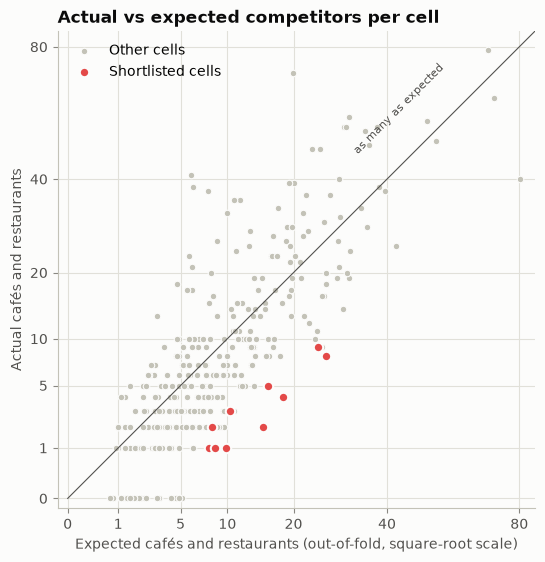

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 6.2))
others = scores.drop(shortlist.index)
ax.scatter(np.sqrt(others["expected"]), np.sqrt(others["competitors"]), s=22, color=AXIS, edgecolor=SURFACE,
           linewidth=0.8, label="Other cells")
ax.scatter(np.sqrt(shortlist["expected"]), np.sqrt(shortlist["competitors"]), s=46, color=RED, edgecolor=SURFACE,
           linewidth=1.5, label="Shortlisted cells", zorder=3)
limit = np.sqrt(max(scores["expected"].max(), scores["competitors"].max())) + 0.3
ax.plot([0, limit], [0, limit], color=INK_2, linewidth=0.8)
ax.annotate("as many as expected", (limit * 0.72, limit * 0.72), xytext=(-4, 6), textcoords="offset points",
            rotation=45, color=INK_2, fontsize=8, ha="center")
ticks = [0, 1, 5, 10, 20, 40, 80]
ax.set_xticks(np.sqrt(ticks), ticks)
ax.set_yticks(np.sqrt(ticks), ticks)
ax.set_xlim(-0.2, limit)
ax.set_ylim(-0.2, limit)
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel("Expected cafés and restaurants (out-of-fold, square-root scale)")
ax.set_ylabel("Actual cafés and restaurants")
ax.set_title("Actual vs expected competitors per cell")
ax.legend(loc="upper left")
save(fig, "fig7_expected_vs_actual")
plt.show()

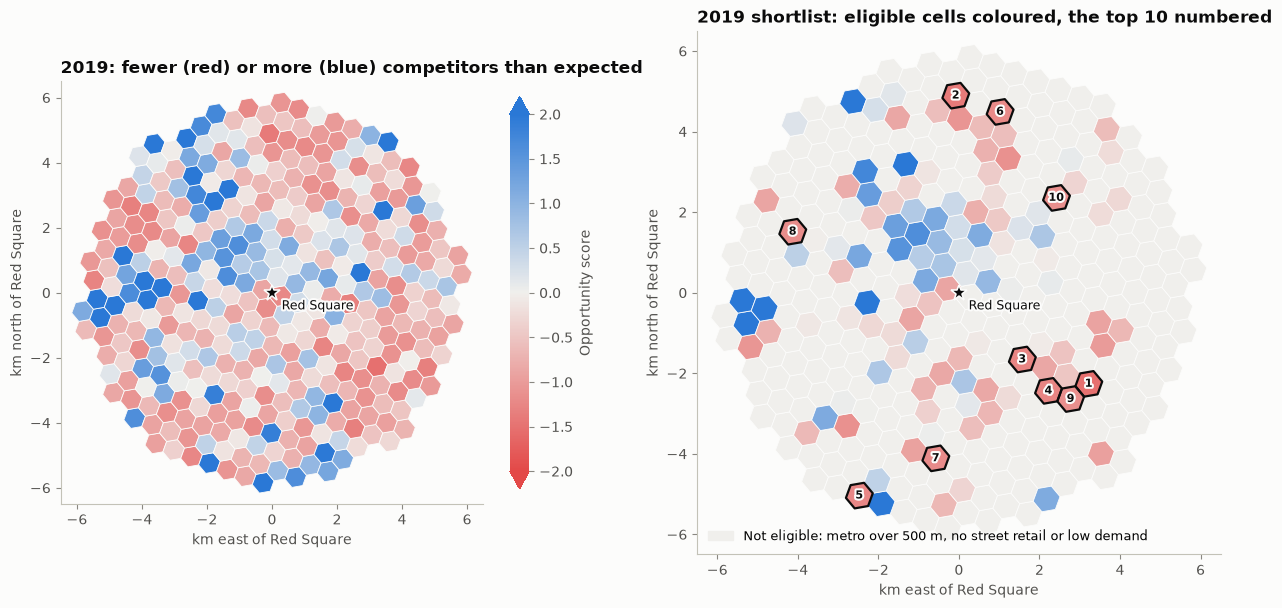

In [22]:
score_norm = Normalize(vmin=-2, vmax=2)


def opportunity_figure(scores, shortlist, year, name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.8))
    tiles = hex_map(axes[0], scores["score"], DIVERGING, score_norm,
                    f"{year}: fewer (red) or more (blue) competitors than expected")
    colorbar = fig.colorbar(tiles, ax=axes[0], shrink=0.75, extend="both")
    colorbar.set_label("Opportunity score", color=INK_2)
    colorbar.outline.set_visible(False)
    hex_map(axes[1], np.zeros(len(cells)), ListedColormap([NEUTRAL]), Normalize(0, 1),
            f"{year} shortlist: eligible cells coloured, the top 10 numbered")
    eligible_cells = scores["eligible"].to_numpy()
    axes[1].add_collection(PolyCollection(HEX_KM[eligible_cells], array=scores.loc[eligible_cells, "score"].to_numpy(),
                                          cmap=DIVERGING, norm=score_norm, edgecolor=SURFACE, linewidth=0.6))
    axes[1].add_collection(PolyCollection(HEX_KM[[cells.index.get_loc(i) for i in shortlist.index]],
                                          facecolor="none", edgecolor=INK, linewidth=1.6))
    for cell_id, row in shortlist.iterrows():
        x, y_km = CELL_KM[cells.index.get_loc(cell_id)]
        axes[1].text(x, y_km, str(row["rank"]), ha="center", va="center", fontsize=8, fontweight="bold", color=INK,
                     path_effects=HALO)
    not_eligible = Patch(color=NEUTRAL, label="Not eligible: metro over 500 m, no street retail or low demand")
    axes[1].legend(handles=[not_eligible], loc="lower left", fontsize=9)
    save(fig, name)
    plt.show()


opportunity_figure(scores, shortlist, 2019, "fig8_opportunity_map_2019")

## 8. Looking forward: 2019 to 2026

The model was fitted on the 2019 register. OpenStreetMap shows where cafés and restaurants are in
2026. If the expected counts capture real demand, the places with fewer venues than expected in
2019 should have gained venues since, and the saturated ones should have lost some. The two
sources count almost the same number of cafés and restaurants around the grid cells, but they are
different sources, so the check compares changes across cells rather than exact counts.

In [23]:
osm_competitors = osm_catering[osm_catering["is_competitor"]]
count_2026 = pd.Series(count_within(xy_array(cells), xy_array(osm_competitors), RADIUS_M), index=cells.index)
growth = np.log((count_2026 + 1) / (y + 1))
print(f"Cafés and restaurants within 300 m of the cells: {y.sum():,} in the 2019 register, "
      f"{count_2026.sum():,} in OpenStreetMap 2026")

quintile_names = ["1: most under-served", "2", "3", "4", "5: most saturated"]
by_quintile = (
    pd.DataFrame({"quintile": pd.qcut(scores["score"], 5, labels=quintile_names), "2019": y, "2026": count_2026})
    .groupby("quintile", observed=True)
    .agg(cells=("2019", "size"), venues_2019=("2019", "sum"), venues_2026=("2026", "sum"))
)
by_quintile["change"] = by_quintile["venues_2026"] / by_quintile["venues_2019"]
by_quintile.round(2)

Cafés and restaurants within 300 m of the cells: 3,659 in the 2019 register, 3,691 in OpenStreetMap 2026


,cells,venues_2019,venues_2026,change
quintile,,,,
1: most under-served,74,130,220,1.69
2,73,337,431,1.28
3,74,635,686,1.08
4,70,1046,1004,0.96
5: most saturated,73,1511,1350,0.89


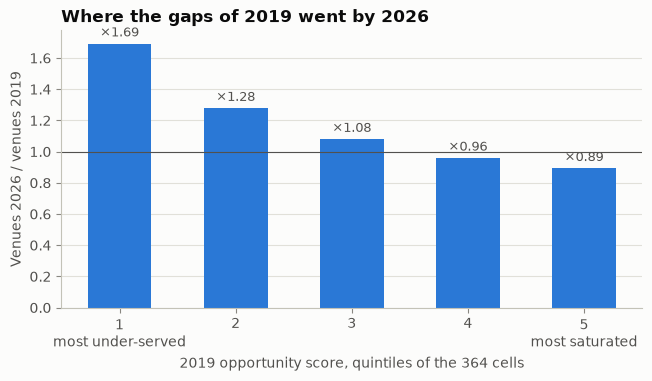

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
bars = ax.bar(range(len(by_quintile)), by_quintile["change"], color=BLUE, width=0.55)
ax.bar_label(bars, labels=[f"×{v:.2f}" for v in by_quintile["change"]], padding=3, color=INK_2, fontsize=9)
ax.axhline(1, color=INK_2, linewidth=0.8)
ax.set_xticks(range(len(by_quintile)), [q.replace(": ", "\n") for q in by_quintile.index])
ax.set_ylabel("Venues 2026 / venues 2019")
ax.set_xlabel("2019 opportunity score, quintiles of the 364 cells")
ax.set_title("Where the gaps of 2019 went by 2026")
ax.yaxis.grid(True)
ax.set_axisbelow(True)
save(fig, "fig9_look_forward")
plt.show()

The under-served fifth of the cells gained the most venues and the saturated fifth lost some.
Part of this is regression to the mean: a count that was unusually low in one source tends to be
higher in another. The test for the model itself is whether the 2019 expectation says anything
about the change once the 2019 count is known: least squares of the log change on both, with a
block bootstrap of the 2 km blocks for the interval.

In [25]:
change_design = np.column_stack([np.ones(len(y)), np.log1p(y), np.log(run["expected"])])


def expectation_slope(design, rows):
    """Coefficient of the log expectation in the least-squares fit of the log change on `design`."""
    coefficients, *_ = np.linalg.lstsq(design[rows], growth.to_numpy()[rows], rcond=None)
    return coefficients[2]


def slope_with_interval(design):
    boot = [expectation_slope(design, rows) for rows in forward_rows]
    return expectation_slope(design, np.arange(len(y))), *np.percentile(boot, [2.5, 97.5])


forward_rng = np.random.RandomState(1)
forward_rows = [
    np.concatenate([np.flatnonzero(blocks == b) for b in forward_rng.choice(block_ids, size=len(block_ids))])
    for _ in range(1000)
]
forward_slope, forward_low, forward_high = slope_with_interval(change_design)
print(f"At equal 2019 counts, twice the expected count means {2**forward_slope - 1:+.0%} more venues by 2026 "
      f"(95% interval {2**forward_low - 1:+.0%} to {2**forward_high - 1:+.0%}).")

shortlist_2026 = shortlist[["rank", "address", "nearest_metro", "competitors"]]
shortlist_2026 = shortlist_2026.assign(in_2026=count_2026[shortlist.index])
print(f"The ten shortlisted cells: {shortlist_2026['competitors'].sum()} cafés and restaurants in 2019, "
      f"{shortlist_2026['in_2026'].sum()} in 2026.")
shortlist_2026.rename(columns={"competitors": "in_2019"})

At equal 2019 counts, twice the expected count means +10% more venues by 2026 (95% interval +1% to +19%).
The ten shortlisted cells: 36 cafés and restaurants in 2019, 69 in 2026.


,rank,address,nearest_metro,in_2019,in_2026
cell_id,,,,,
149,1,"Stroykovskaya Street, 10",Пролетарская,1,7
337,2,4th Maryinoy Roschi Drive,Марьина роща,4,7
146,3,Goncharnaya Embankment,Таганская,2,7
128,4,"Krestyanskaya Square, 10с28",Пролетарская,1,2
2,5,"Leninsky Avenue, 39с1",Ленинский проспект,1,5
339,6,"Tsentralniy Administrative Okrug, Meschanskiy ...",Рижская,2,0
38,7,Khavskaya Street,Шаболовская,3,4
174,8,"Sergeya Makeyeva Street, 12",Улица 1905 года,5,7
129,9,"Krutitsky Val Street, 3с1",Пролетарская,9,9


### The market, or the years 2020-2026?

The seven years between the sources were not ordinary ones. The pandemic and remote work, the war
and the sanctions, the exit of foreign chains (Starbucks, McDonald's and KFC reopened under new
names) and the collapse of foreign tourism moved demand from some kinds of places to others. If the
historic centre simply lost its tourists and office workers, the check above would reward any
model that expects many cafés there. Three checks separate the model from these shocks: the
quintiles beyond 3 km from Red Square, well outside the Garden Ring; the fit above with the
distance to Red Square added; and the change by type of place.

In [26]:
distance_design = np.column_stack([change_design, features["center_distance"] / 1000])
distance_slope, distance_low, distance_high = slope_with_interval(distance_design)
print(f"With the distance to Red Square in the fit, twice the expected count means {2**distance_slope - 1:+.0%} "
      f"(95% interval {2**distance_low - 1:+.0%} to {2**distance_high - 1:+.0%}).")

outer = features["center_distance"] > 3000
outer_quintiles = (
    pd.DataFrame({"quintile": pd.qcut(scores["score"], 5, labels=quintile_names), "2019": y, "2026": count_2026})
    .loc[outer]
    .groupby("quintile", observed=True)[["2019", "2026"]]
    .sum()
)
outer_change = outer_quintiles["2026"] / outer_quintiles["2019"]
print(f"Beyond 3 km from Red Square ({outer.sum()} cells), venues 2026 / 2019 by quintile: "
      + ", ".join(f"×{value:.2f}" for value in outer_change))

by_type = (
    pd.DataFrame({"type": cluster, "venues_2019": y, "venues_2026": count_2026})
    .groupby("type")
    .agg(cells=("venues_2019", "size"), venues_2019=("venues_2019", "sum"), venues_2026=("venues_2026", "sum"))
    .reindex(CLUSTER_ORDER)
)
by_type["change"] = by_type["venues_2026"] / by_type["venues_2019"]
by_type.round(2)

With the distance to Red Square in the fit, twice the expected count means +4% (95% interval -5% to +13%).
Beyond 3 km from Red Square (268 cells), venues 2026 / 2019 by quintile: ×1.62, ×1.37, ×1.11, ×1.09, ×0.83


,cells,venues_2019,venues_2026,change
type,,,,
Transit hubs,45,1284,1126,0.88
Central neighbourhoods,76,1430,1428,1.00
Residential belt,157,847,936,1.11
"Parks, rail and industrial land",86,98,201,2.05


* The pattern holds beyond 3 km from Red Square: it is not only the tourist centre emptying out.
* The model's own share is hard to separate from location. With the distance to Red Square in the
  fit, the effect of the expectation shrinks and its interval includes zero.
* Much of the change follows the kind of place: transit hubs lost venues (the streets around the
  Kremlin, the Expocentre, big shopping malls), the residential belt gained, and parks and former
  industrial land roughly doubled from a low base. OpenStreetMap also maps venues inside malls and
  exhibition halls less completely than the register did, which adds to the losses of the hubs.

So the check against 2026 agrees with the model in direction but does not prove it: seven years
of shocks moved the market in the same direction. Eight of the ten cells shortlisted in 2019 gained
venues by 2026.

## 9. The shortlist for 2026

Gaps tend to close, so a café opened now has to be placed against today's market: the cafés and
restaurants of OpenStreetMap 2026 as competitors, and the footfall generators of 2026 as well, from
the same snapshot (`scripts/fetch_osm_data.py demand`). The OpenStreetMap tags are chosen to match
the registers of 2019:

* **Metro**: entrances of metro, MCC and MCD stations, so the Big Circle Line and the MCD lines
  opened since 2019 are in.
* **Stops**: bus, trolleybus and tram stops.
* **Shops**: every shop except empty premises, street kiosks and car repair; parcel pick-up points
  of online stores, rare in 2019, are counted as shops.
* **Consumer services**: the categories of the 2019 register (hairdressers and beauty salons,
  tailors, photo studios, repairs, dry cleaning, pawnshops, keys, watches, saunas).
* **Gyms**: fitness centres. The 2019 layer held municipal sports centres, a different thing.
* **Parking** keeps the 2019 layer, because OpenStreetMap rarely records the capacity of Moscow's
  street parking; universities already come from OpenStreetMap.

Counts within 6 km of Red Square:

In [27]:
footfall_2026 = data.load_osm_demand()
footfall_names = {
    "metro": "Metro entrances (2026: metro, MCC and MCD)",
    "bus": "Bus and tram stops",
    "shops": "Shops",
    "services": "Consumer services",
    "fitness": "Gyms (2019: municipal sports centres)",
}


def within_6km(frame):
    return int((distance_from(frame, *RED_SQUARE) <= 6000).sum())


footfall_counts = pd.DataFrame(
    {year: {footfall_names[k]: within_6km(source[k]) for k in footfall_names}
     for year, source in (("2019", layers), ("2026", footfall_2026))}
)
footfall_counts

,2019,2026
"Metro entrances (2026: metro, MCC and MCD)",289,349
Bus and tram stops,1654,1772
Shops,12695,9686
Consumer services,3031,3328
Gyms (2019: municipal sports centres),43,178


The same pipeline, now with every layer from 2026 except parking. The table also shows the 2019
score and the count of the 2019 register (a cell that was under-served in both sources is less
likely to be an artefact of either) and the rank the cell gets when the footfall layers are those
of 2019.

In [28]:
layers_2026 = {**layers, **footfall_2026, "catering": osm_catering}
features_by_radius_2026 = {r: build_features(cells, **layers_2026, radius=r) for r in RADII}
features_2026 = features_by_radius_2026[RADIUS_M]
score_2026, eligible_2026, runs_2026 = multi_scale(features_by_radius_2026)
run_2026, theta_2026 = opportunity(features_2026)
d2_2026 = d2(features_2026["competitors"], run_2026["expected"])
print(f"2026 model: D² = {d2_2026:.2f} under spatial cross-validation, negative binomial θ = {theta_2026:.2f}; "
      f"{eligible_2026.sum()} of {len(cells)} cells are eligible")

# The variant with the footfall layers of 2019, for comparison.
old_footfall = {r: build_features(cells, **{**layers, "catering": osm_catering}, radius=r) for r in RADII}
old_score, old_eligible, _ = multi_scale(old_footfall)
d2_old_footfall = d2(old_footfall[RADIUS_M]["competitors"], opportunity(old_footfall[RADIUS_M])[0]["expected"])
print(f"With the footfall layers of 2019 instead: D² = {d2_old_footfall:.2f}")

scores_2026 = score_table(features_2026, run_2026["expected"], score_2026, eligible_2026, footfall_2026["metro"])
shortlist_now = top_ten(scores_2026)
ranks_2026 = pd.DataFrame(
    {f"rank at {r} m": runs_2026[r]["gap"].where(runs_2026[r]["eligible"]).rank(method="min") for r in RADII}
).loc[shortlist_now.index].astype("Int64")
old_rank = old_score.where(old_eligible).rank(method="min").loc[shortlist_now.index].astype("Int64")
fast_food_score_2026, fast_food_eligible_2026, _ = multi_scale(features_by_radius_2026, ("competitors", "fast_food"))
kept_2026 = shortlist_now.index.intersection(fast_food_score_2026[fast_food_eligible_2026].nsmallest(10).index)
print(f"{len(kept_2026)} of the 10 stay in the top 10 when fast food counts as competition too")
shortlist_now[["rank", "address", "nearest_metro", "metro_m", "center_km", "competitors", "expected", "score"]].assign(
    in_2019=y[shortlist_now.index],
    score_2019=scores.loc[shortlist_now.index, "score"],
    rank_2019_footfall=old_rank,
).join(ranks_2026)

2026 model: D² = 0.67 under spatial cross-validation, negative binomial θ = 4.96; 126 of 364 cells are eligible


With the footfall layers of 2019 instead: D² = 0.58


7 of the 10 stay in the top 10 when fast food counts as competition too


,rank,address,nearest_metro,metro_m,center_km,competitors,expected,score,in_2019,score_2019,rank_2019_footfall,rank at 250 m,rank at 300 m,rank at 400 m
cell_id,,,,,,,,,,,,,,
330,1,"Rusakovskaya Street, 8с3",Митьково,347.0,4.5,0,7.2,-1.82,2,-0.94,<NA>,1,1,<NA>
60,2,"Kutuzovsky Avenue, 35",Кутузовская,309.0,5.3,1,9.5,-1.67,2,-1.07,4,3,2,1
324,3,Festivalny Park,Марьина Роща,248.0,4.3,1,7.9,-1.58,3,-1.09,3,6,4,2
303,4,Soldatsky Lane,Лефортово,228.0,5.3,2,10.8,-1.56,2,-0.50,<NA>,4,5,<NA>
307,5,Savyolovsky Drive,Савёловская,381.0,4.6,1,8.1,-1.55,9,-0.87,1,7,3,3
343,6,Shumkina Street,Митьково,282.0,4.9,1,7.5,-1.45,3,-0.60,<NA>,5,6,<NA>
188,7,"Rogozhsky Val Street, 9/2с2",Римская,440.0,3.8,4,11.9,-1.33,8,-1.01,6,21,10,4
61,8,Kiyevskaya Street,Студенческая,6.0,4.9,4,10.2,-1.33,5,-0.47,11,15,19,5
192,9,"Khoroshyovskoye Highway, вл1",Беговая,4.0,5.3,4,10.4,-1.31,8,-0.89,5,8,17,7


* With the footfall layers of 2026 the model explains the 2026 market as well as the 2019 model
  explained 2019 (D² 0.67), against 0.58 when the layers of 2019 stand in for 2026: seven years of
  change in shops, services and stations matter.
* Three of the ten are next to stations opened since 2019: #1 and #6 by Mitkovo on the MCD, #4 by
  Lefortovo on the Big Circle Line, where the nearest metro exit was 1.6 km away in 2019. The
  model expects cafés there because of the new footfall, and few have opened yet.
* The Dubrovka market cell leaves the list: the register counted its 1,316 stalls as shops,
  OpenStreetMap maps 23 shops there. The Rizhskaya cell drops below the filters too, with fewer
  shops and services mapped around it. Both are gaps in the data, not in the market.
* Six of the ten were in the top 10 with the footfall layers of 2019 as well.

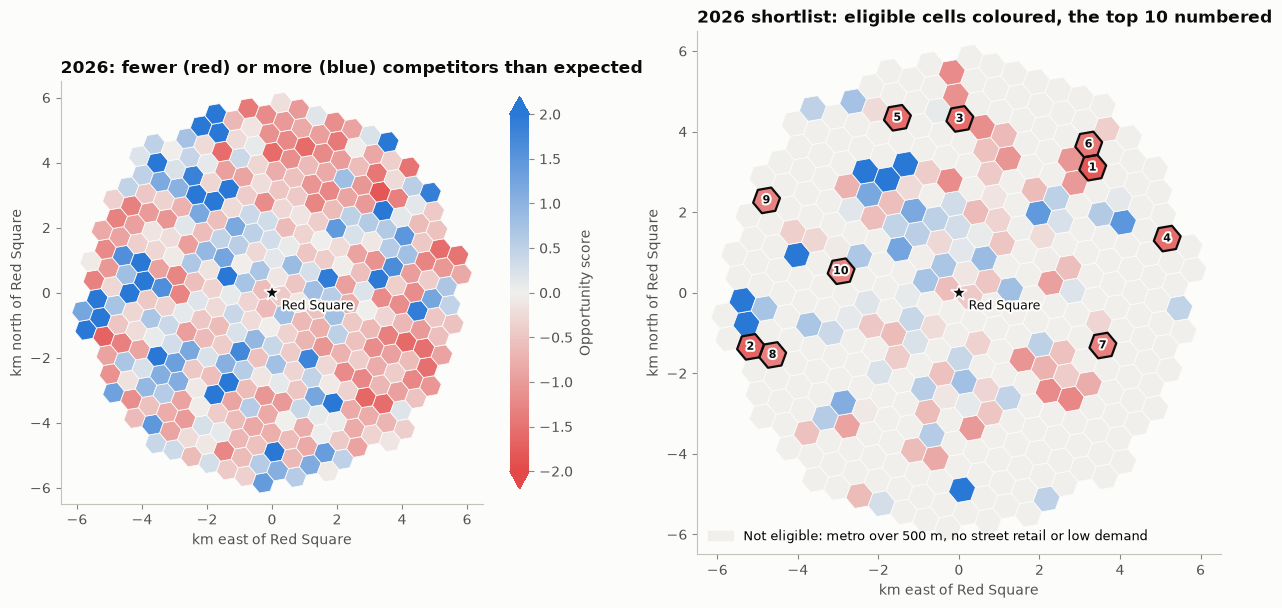

In [29]:
opportunity_figure(scores_2026, shortlist_now, 2026, "fig10_opportunity_map_2026")

### Interactive map

The 2026 scores with the 2026 shortlist; the 2019 scores and shortlist are extra layers. Hover a
cell for its numbers. The map is also saved as `report/cafe_opportunity_map.html`.

In [30]:
score_colors = bcm.LinearColormap([RED, NEUTRAL, BLUE], vmin=-2, vmax=2,
                                  caption="Opportunity score: red = fewer cafés and restaurants than expected")
map_columns = ["address", "type", "nearest_metro", "metro_m", "competitors", "expected", "score", "eligible"]
map_aliases = ["Address", "Type", "Nearest metro", "Metro exit, m", "Cafés and restaurants", "Expected", "Score",
               "Eligible"]
opportunity_map = base_map()
for year, year_scores, show in ((2026, scores_2026, True), (2019, scores, False)):
    table = year_scores.assign(eligible=year_scores["eligible"].map({True: "yes", False: "no"}))[map_columns]
    hex_layer(table, year_scores["score"].clip(-2, 2).map(score_colors), map_columns, map_aliases,
              f"Opportunity score {year}", opacity=0.6, show=show).add_to(opportunity_map)
for year, year_shortlist, show in ((2026, shortlist_now, True), (2019, shortlist, False)):
    shortlist_layer = folium.FeatureGroup(name=f"Shortlist {year}", show=show)
    background, foreground = (INK, SURFACE) if year == 2026 else (SURFACE, INK)
    for _, row in year_shortlist.iterrows():
        popup = (f"<b>{year} #{row['rank']} {escape(row['address'])}</b><br>Metro {escape(row['nearest_metro'])}, "
                 f"{row['metro_m']:.0f} m<br>{row['competitors']} cafés and restaurants within 300 m, "
                 f"{row['expected']:.0f} expected<br>{row['shops']} shops, {row['services']} services")
        folium.Marker(
            [row["lat"], row["lon"]],
            icon=folium.DivIcon(
                html=f'<div style="width:24px;height:24px;border-radius:12px;background:{background};'
                     f'color:{foreground};border:2px solid {INK};box-sizing:border-box;'
                     f'font:600 12px/20px system-ui,sans-serif;text-align:center">{row["rank"]}</div>',
                icon_size=(24, 24), icon_anchor=(12, 12)),
            tooltip=f"{year} #{row['rank']} {escape(row['address'])}",
            popup=folium.Popup(popup, max_width=320),
        ).add_to(shortlist_layer)
    shortlist_layer.add_to(opportunity_map)
score_colors.add_to(opportunity_map)
folium.LayerControl(collapsed=False).add_to(opportunity_map)
opportunity_map.save(REPORT / "cafe_opportunity_map.html")

# Columns that differ between the years get a _2019 or _2026 suffix.
year_columns = ["nearest_metro", "metro_m", "shops", "services", "competitors", "expected", "score", "eligible"]
cell_scores = scores.drop(columns=year_columns).join(scores[year_columns].add_suffix("_2019")).join(
    scores_2026[year_columns].add_suffix("_2026")
)
cell_scores.to_csv(REPORT / "cell_scores.csv", index_label="cell_id")
shortlist.drop(columns=["eligible"]).to_csv(REPORT / "shortlist_2019.csv", index_label="cell_id")
shortlist_now.drop(columns=["eligible"]).to_csv(REPORT / "shortlist_2026.csv", index_label="cell_id")
opportunity_map

In [31]:
# The numbers quoted in the report, for scripts/build_report_page.py.
def as_json(obj, orient=None):
    """A pandas object as plain JSON values (numpy types become Python ones, NaN becomes null)."""
    return json.loads(obj.to_json(orient=orient, force_ascii=False))


profile_columns = ["cells", "competitors", "metro_exits", "shops", "services", "metro_distance", "center_distance"]
summary = {
    "osm_date": osm_date,
    "catering_within_6km": as_json(composition["venues"]),
    "competitors_within_6km": len(competitors),
    "competitor_seats": int(competitors["seats"].sum()),
    "chain_share": float(competitors["is_chain"].mean()),
    "top_chains": as_json(chain_counts.head(15)),
    "spearman": as_json(rho),
    "typology": as_json(cluster_profile[profile_columns], orient="index"),
    "silhouette_k4": float(k_scores.loc[K, "silhouette"]),
    "model_d2": as_json(model_comparison.iloc[:, 0]),
    "random_cv_d2": float(random_cv_d2),
    "alpha": float(ALPHA),
    "effects": as_json(effects, orient="index"),
    "dispersion": float(dispersion),
    "theta": float(theta),
    "eligible_cells": int(eligible.sum()),
    "single_radius_ranks": as_json(single_radius_ranks.astype(float), orient="index"),
    "kept_with_fast_food": [int(rank) for rank in shortlist.loc[kept, "rank"]],
    "look_forward": {
        "venues_2019": int(y.sum()),
        "venues_2026": int(count_2026.sum()),
        "by_quintile": as_json(by_quintile.reset_index(), orient="records"),
        "slope": float(forward_slope),
        "slope_low": float(forward_low),
        "slope_high": float(forward_high),
        "distance_slope": float(distance_slope),
        "distance_slope_low": float(distance_low),
        "distance_slope_high": float(distance_high),
        "outer_cells": int(outer.sum()),
        "outer_change": [float(value) for value in outer_change],
        "by_type": as_json(by_type, orient="index"),
        "shortlist": as_json(shortlist_2026.reset_index(), orient="records"),
    },
    "most_saturated": as_json(
        scores.sort_values("score", ascending=False).head(6)[
            ["address", "nearest_metro", "type", "competitors", "expected", "score"]
        ].reset_index(),
        orient="records",
    ),
}
osm_central = osm_catering[distance_from(osm_catering, *RED_SQUARE) <= 6000]
summary["now"] = {
    "osm_catering_within_6km": as_json(osm_central["amenity"].value_counts()),
    "competitors_within_6km": int(osm_central["is_competitor"].sum()),
    "footfall_within_6km": as_json(footfall_counts.set_axis(list(footfall_names), axis=0), orient="index"),
    "d2": float(d2_2026),
    "d2_2019_footfall": float(d2_old_footfall),
    "ranks_with_2019_footfall": as_json(old_rank.astype(float)),
    "theta": float(theta_2026),
    "eligible_cells": int(eligible_2026.sum()),
    "single_radius_ranks": as_json(ranks_2026.astype(float), orient="index"),
    "kept_with_fast_food": [int(rank) for rank in shortlist_now.loc[kept_2026, "rank"]],
}
_ = (REPORT / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=1) + "\n", encoding="utf-8")

## 10. Results and discussion

### Results

* **The market in 2019.** Within 6 km of Red Square the city register lists 5,784 catering
  venues, 3,956 of them cafés and restaurants with 233,000 seats. Chains run 22% of the cafés and
  restaurants; the largest ones sell coffee (Шоколадница, Prime, Starbucks).
* **Where cafés are.** Competitor density rises with shops and consumer services (Spearman
  ρ = 0.73 for both), parking spaces (0.47) and metro exits (0.40), and falls with the distance to
  the nearest metro exit (−0.53) and to Red Square (−0.56).
* **Four types of places.** k-means splits the 364 cells into transit hubs (45), central
  neighbourhoods (76), the residential belt (157) and parks, rail and industrial land (86).
* **Demand model.** The footfall generators explain 67% of the Poisson deviance of the competitor
  counts under spatial cross-validation (Poisson GLM; gradient boosting reaches 63%). Each
  kilometre away from Red Square takes about 22% off the expected number of cafés and restaurants,
  each 100 m away from the nearest metro exit about 4.5%; twice as many shops add about 26%, twice
  as many consumer services about 18%, twice as many metro exits about 8%. The effects of parking,
  bus stops, universities and gyms cannot be told apart from zero.
* **The 2019 shortlist.** 117 cells pass the eligibility filters. The ten with the largest
  shortfall of competitors in 2019 (counts and expectations for the 300 m catchment):

In [32]:
summary_columns = ["rank", "address", "nearest_metro", "metro_m", "center_km", "competitors", "expected", "score"]
shortlist[summary_columns].set_index("rank")

,address,nearest_metro,metro_m,center_km,competitors,expected,score
rank,,,,,,,
1,"Stroykovskaya Street, 10",Пролетарская,366.0,3.9,1,9.8,-1.53
2,4th Maryinoy Roschi Drive,Марьина роща,114.0,4.9,4,18.2,-1.40
3,Goncharnaya Embankment,Таганская,377.0,2.3,2,14.9,-1.27
4,"Krestyanskaya Square, 10с28",Пролетарская,411.0,3.3,1,7.8,-1.27
5,"Leninsky Avenue, 39с1",Ленинский проспект,138.0,5.6,1,8.5,-1.24
6,"Tsentralniy Administrative Okrug, Meschanskiy ...",Рижская,171.0,4.6,2,8.2,-1.21
7,Khavskaya Street,Шаболовская,417.0,4.2,3,10.3,-1.20
8,"Sergeya Makeyeva Street, 12",Улица 1905 года,326.0,4.4,5,15.8,-1.18
9,"Krutitsky Val Street, 3с1",Пролетарская,134.0,3.8,9,24.6,-1.15


* **The check against 2026.** The fifth of the cells that were most under-served in 2019 had 69%
  more cafés and restaurants in OpenStreetMap 2026 than in the 2019 register; the most saturated
  fifth had 11% fewer, and the pattern holds beyond 3 km from Red Square. At equal 2019 counts,
  twice the expected count meant about 10% more venues by 2026 (95% interval +1% to +19%), but with
  the distance to Red Square in the fit the effect shrinks to about 4% and its interval includes
  zero. The years 2020-2026 moved venues between kinds of places: transit hubs lost 12%, the
  residential belt gained 11%. The ten cells of the 2019 shortlist went from 36 venues to 69.
* **The 2026 shortlist.** With the competitors and the footfall layers of 2026 the model explains
  67% of the deviance, as much as in 2019 (58% with the footfall layers of 2019). The ten most
  under-served eligible cells of 2026, with the count of the 2019 register for comparison:

In [33]:
shortlist_now[summary_columns].assign(in_2019=y[shortlist_now.index]).set_index("rank")

,address,nearest_metro,metro_m,center_km,competitors,expected,score,in_2019
rank,,,,,,,,
1,"Rusakovskaya Street, 8с3",Митьково,347.0,4.5,0,7.2,-1.82,2
2,"Kutuzovsky Avenue, 35",Кутузовская,309.0,5.3,1,9.5,-1.67,2
3,Festivalny Park,Марьина Роща,248.0,4.3,1,7.9,-1.58,3
4,Soldatsky Lane,Лефортово,228.0,5.3,2,10.8,-1.56,2
5,Savyolovsky Drive,Савёловская,381.0,4.6,1,8.1,-1.55,9
6,Shumkina Street,Митьково,282.0,4.9,1,7.5,-1.45,3
7,"Rogozhsky Val Street, 9/2с2",Римская,440.0,3.8,4,11.9,-1.33,8
8,Kiyevskaya Street,Студенческая,6.0,4.9,4,10.2,-1.33,5
9,"Khoroshyovskoye Highway, вл1",Беговая,4.0,5.3,4,10.4,-1.31,8


### Discussion

**Gaps tend to close, and the model is not the only reason.** The under-served cells of 2019 gained
venues and the saturated ones lost some, also outside the historic centre. Yet 2020-2026 brought
the pandemic, remote work, the war and sanctions, the exit of foreign chains and the collapse of
foreign tourism, and these shocks moved cafés away from transit hubs and towards residential
streets, the same direction the model points to. With the distance to Red Square taken into
account, the check can no longer tell the model's demand estimate from regression to the mean and
from those shocks. What it does show is that gaps do not stay open for long, so the shortlist has
to be rebuilt on fresh data, as section 9 does, and acted on quickly.

**The historic core is taken.** No 2026 candidate lies inside the Garden Ring: the centre has as
many cafés as its footfall generators suggest, or more. The only such cell on the 2019 list,
Goncharnaya Embankment by Taganskaya, has gained five venues since. The 2026 candidates are
3.0-5.3 km from Red Square, around the Third Ring Road, within 440 m of a metro exit.

**New stations, new gaps.** #1 and #6 lie by Mitkovo, a station of the MCD, and #4 by Lefortovo, a
station of the Big Circle Line opened in 2023; in 2019 these places were far from any metro exit.
Their gaps are the youngest on the list and the least tested: none of the three is eligible with
the 400 m catchment.

**The most robust candidates** are #2 Kutuzovskaya, #3 Maryina Roshcha and #5 Savyolovskaya. They
are eligible with every catchment and rank in the top 12 with each, stay in the top 10 when fast
food counts as competition too, were under-served in the 2019 register as well, and are in the top
5 also with the footfall layers of 2019.

**Check the counts before the visit.** OpenStreetMap misses venues, most often inside markets and
malls. At #5 Savyolovskaya the register listed 9 venues, all in the Savyolovsky market complex
(Sushchyovsky Val, 5), and OpenStreetMap lists 1. The cell stays a candidate because it was
under-served in 2019 too, with 9 venues where 25 were expected.

**What the model does not see.** The cells with the largest surplus of competitors in 2019:

In [34]:
scores.sort_values("score", ascending=False).head(6)[
    ["address", "nearest_metro", "type", "competitors", "expected", "score"]
]

,address,nearest_metro,type,competitors,expected,score
cell_id,,,,,,
254,"Miusskaya Square, 5",Белорусская,Central neighbourhoods,41,6.0,10.60
316,"Baumanskaya Street, 5с1",Бауманская,Central neighbourhoods,38,6.2,8.75
78,Testovskaya Street,Международная,Residential belt,37,7.7,5.99
137,Krasnopresnenskaya Embankment,Краснопресненская,Residential belt,23,5.8,4.91
96,1st Krasnogvardeysky Drive,Деловой центр,Transit hubs,26,8.7,4.13
136,1905 Goda Street,Улица 1905 года,Central neighbourhoods,32,10.0,4.07


The Depo food mall on Lesnaya Street near Belorusskaya (the register lists its counters as some
thirty *Веранда* restaurants), some thirty small cafés at one address on Nizhnyaya Krasnoselskaya
Street near Baumanskaya, the Moscow City towers, the Hotel Ukraina with the Trekhgornaya
Manufaktura business quarter, and the World Trade Center: food halls, offices and hotels draw far
more cafés than shops and metro exits predict. The same blind spot can make a place look
under-served when its demand comes from something the data does not hold.

**Limitations.**

* Each year uses one vintage: the registers of 2019 for 2019 and OpenStreetMap for 2026, apart
  from the universities (OpenStreetMap in both) and parking (the 2019 layer in both, because
  OpenStreetMap rarely records the capacity of street parking). OpenStreetMap maps shops and
  services less completely than the registers did and hardly maps market stalls, and its gyms are
  commercial fitness centres, while the 2019 layer held municipal sports centres.
* The layers count shops, services and station entrances, not people. The pandemic, remote work,
  the war and sanctions, the exit of foreign chains and the fall of foreign tourism changed how
  many people pass them, and that the data does not show.
* The check against 2026 compares two different sources. Their totals around the grid agree
  (3,659 and 3,691 venues), but OpenStreetMap misses venues in markets and malls and tags some
  coffee counters as fast food, so a single cell can change for reasons that have nothing to do
  with the market.
* Competitors are counted, not weighed: a ten-seat coffee counter counts as much as a 200-seat
  restaurant, and price level and concept are ignored. The register's seat counts could weigh the
  venues of 2019; OpenStreetMap has no such field.
* There is no data on rents, pedestrian counts, office floor space or incomes; the distance to Red
  Square stands in for tourists and offices.

**Next steps.** Visit the shortlisted places at peak hours, check vacant premises and asking rents,
add office and footfall data (business centres, mobile-operator counts), and rebuild the shortlist
every year or two: the gaps do not stay open.

## 11. Conclusion

The project looked for places in central Moscow where a new café would share the local footfall
with fewer competitors than usual. The Moscow open data of 2019 on catering, transport, retail and
services were combined on a grid of 364 cells, and a count model learned how many cafés and
restaurants a place normally has given what surrounds it (67% of the deviance explained under
spatial cross-validation). Comparing that expectation with reality shows a saturated historic core
and, mostly 3-6 km from Red Square, places next to metro stations with markedly fewer cafés than
expected.

Seven years later the places the model found under-served in 2019 had 69% more cafés and
restaurants, the saturated ones 11% fewer. The direction agrees with the model, but those were
years of pandemic, war and sanctions that moved cafés from hubs to residential streets on their
own, so the check supports the method without proving it. Run with the competitors and the
footfall generators of 2026, the same method explains the market of 2026 as well (67% of the
deviance) and points to Kutuzovskaya, Maryina Roshcha and Savyolovskaya as the strongest candidates
today, with new gaps next to the stations opened since 2019.

The analysis narrows the search from the whole centre to about ten places. The final choice needs
what open data cannot give: a walk around at rush hour, the rent and the concept.